#  Problem Statement

In [118]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [119]:
df=pd.read_csv("EV Charging Behavior Dataset.csv")

# Data Preprocessing

In [120]:
df.head()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


In [121]:
df.shape

(18946, 18)

In [122]:
df.describe()

,User_ID,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
count,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000
mean,9473.500000,42.919930,35.027890,19.496358,450.124728,1399.960044,0.408266,2.489866,24.096749,5.510767,62.940257,0.443999,87.653957
std,5469.383436,12.915867,10.047099,8.656905,120.149182,635.388130,0.491526,1.701978,13.583756,2.870352,32.274571,0.496867,25.041681
min,1.000000,21.000000,-8.000000,5.000000,-85.560000,300.000000,0.000000,0.000000,1.000000,1.000000,-14.100000,0.000000,0.000000
25%,4737.250000,32.000000,28.300000,12.000000,370.190000,848.250000,0.000000,1.000000,12.000000,3.000000,43.100000,0.000000,90.360000
50%,9473.500000,43.000000,35.100000,19.000000,449.640000,1399.500000,0.000000,2.000000,24.000000,6.000000,55.600000,0.000000,100.000000
75%,14209.750000,54.000000,41.900000,27.000000,530.467500,1951.000000,1.000000,4.000000,36.000000,8.000000,71.000000,1.000000,100.000000
max,18946.000000,65.000000,72.500000,34.000000,901.220000,2499.000000,1.000000,5.000000,47.000000,10.000000,278.200000,1.000000,100.000000


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

# Feature Engineering

In [124]:
df.isnull().sum()

User_ID                         0
Age                             0
City_Tier                       0
EV_Type                         0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
dtype: int64

In [125]:
df.duplicated().sum()

np.int64(0)

In [126]:
df.columns

Index(['User_ID', 'Age', 'City_Tier', 'EV_Type', 'Battery_Capacity_kWh',
       'Charging_Sessions_Per_Month', 'Avg_Charge_Cost',
       'Distance_Travelled_Per_Month', 'Income_Level', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'Charging_Location_Type',
       'App_Usage_Score', 'Charger_Working_Status', 'Charging_Time_Minutes',
       'High_Default_Risk', 'Charging_Efficiency_Index'],
      dtype='object')

In [127]:
numerical_col=df.select_dtypes(["int","float"]).columns

In [128]:
numerical_col

Index(['User_ID', 'Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes', 'High_Default_Risk',
       'Charging_Efficiency_Index'],
      dtype='object')

In [129]:
categorical_col=df.select_dtypes(["object"]).columns

In [130]:
categorical_col

Index(['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status'],
      dtype='object')

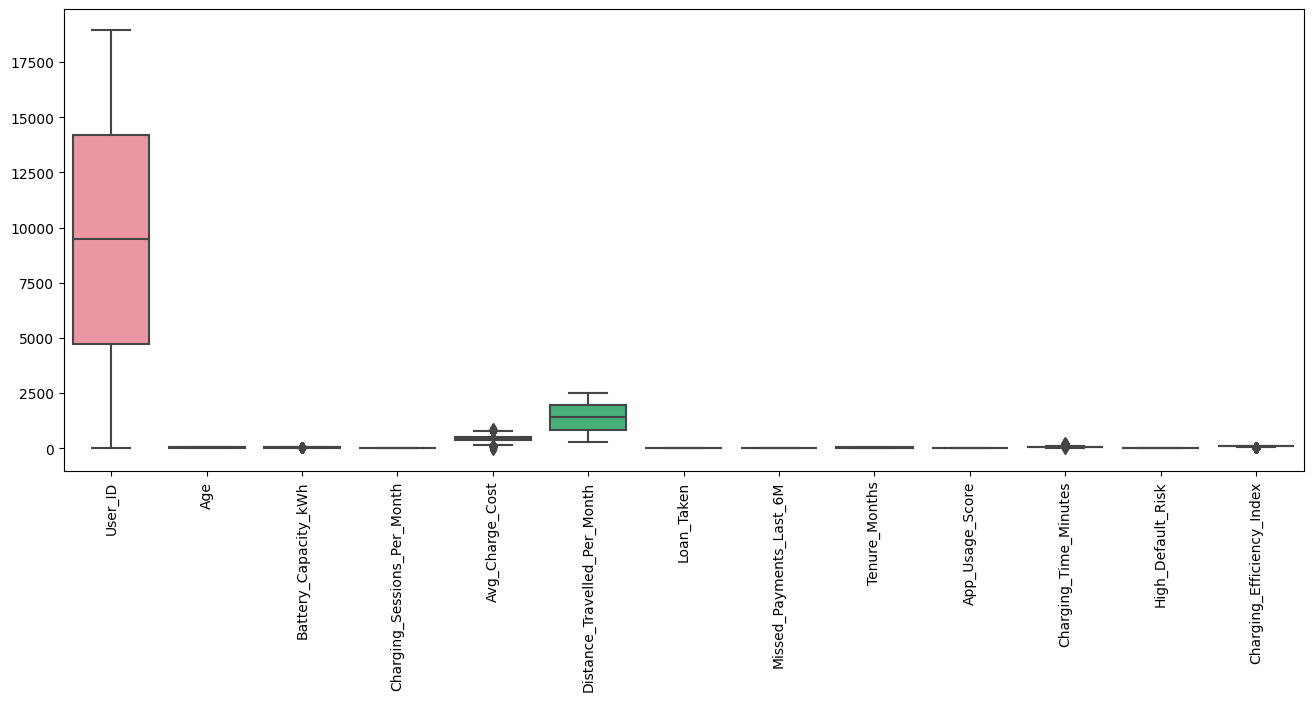

In [131]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

In [132]:
for _ in range(4):
    for col in numerical_col:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)

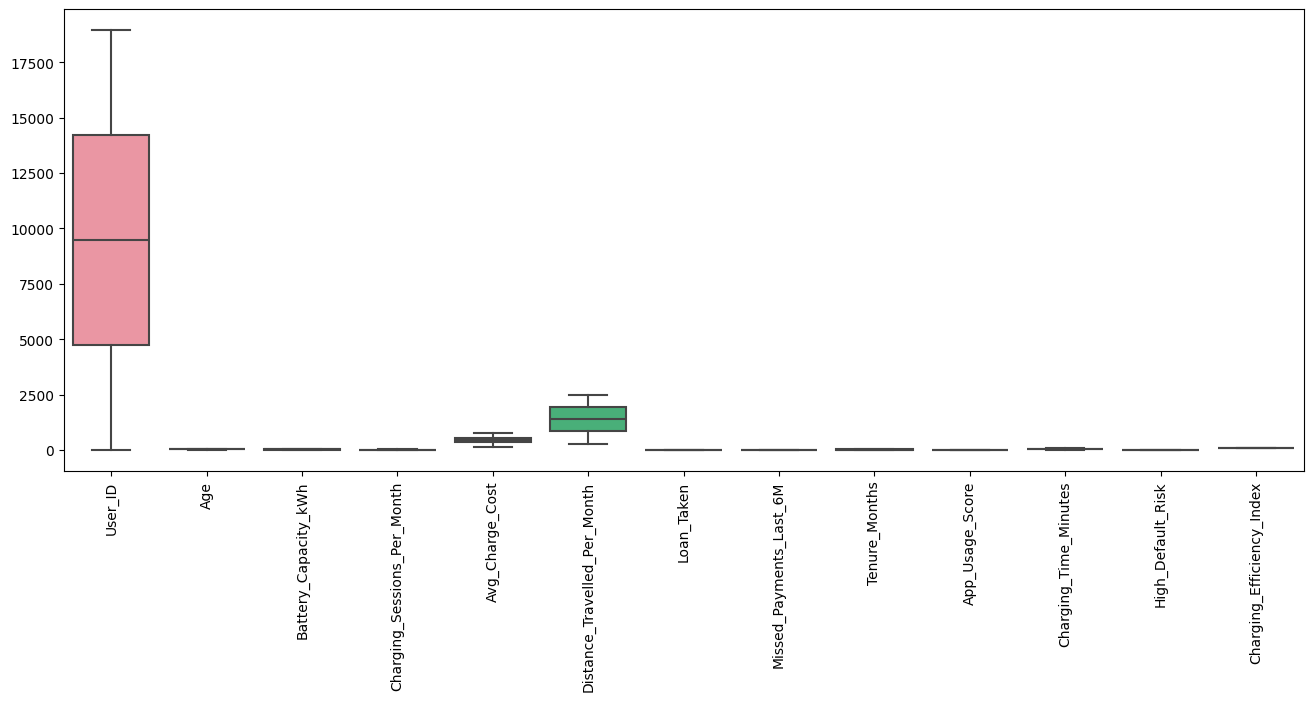

In [133]:
plt.figure(figsize=(16,6))
sns.boxplot(df)
plt.xticks(rotation=90);

 # Model Selection

In [134]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["High_Default_Risk"])
y = df["High_Default_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2,random_state=42,
)

In [135]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (15156, 17)
X_test : (3790, 17)
y_train: (15156,)
y_test : (3790,)


In [136]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
pipe=Pipeline(steps=[("t1",ColumnTransformer(transformers=[("t1",OrdinalEncoder(),['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status']),
                                    ("t2",StandardScaler(),['User_ID', 'Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes','Charging_Efficiency_Index'])])),
                     ("t3",KNeighborsClassifier())])

In [137]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('t3', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('t1', ...), ('t2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [138]:
y_pred=pipe.predict(X_test)

In [139]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
print("Accuracy Score of KNN is ",score)

Accuracy Score of KNN is  0.8240105540897098


In [140]:
from sklearn.metrics import f1_score
f1=f1_score(y_pred,y_test)
print(f1)

0.8015471585837548


In [141]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
pipe=Pipeline(steps=[("t1",ColumnTransformer(transformers=[("t1",OrdinalEncoder(),['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status']),
                                    ("t2",StandardScaler(),['User_ID', 'Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes','Charging_Efficiency_Index'])])),
                     ("t3",DecisionTreeClassifier())])

In [142]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('t3', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('t1', ...), ('t2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [143]:
y_pred=pipe.predict(X_test)

In [146]:
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import f1_score
score=accuracy_score(y_pred,y_test)
print("Accuracy Score of Decision Tree ",score)
f1=f1_score(y_pred,y_test)
print("f1 Score of Decision Tree ",f1)

Accuracy Score of Decision Tree  0.9976253298153034
f1 Score of Decision Tree  0.9973285841495992


In [147]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
pipe=Pipeline(steps=[("t1",ColumnTransformer(transformers=[("t1",OrdinalEncoder(),['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status']),
                                    ("t2",StandardScaler(),['User_ID', 'Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes','Charging_Efficiency_Index'])])),
                     ("t3",LogisticRegression())])

In [148]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('t3', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('t1', ...), ('t2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [149]:
y_pred=pipe.predict(X_test)

In [150]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
score=accuracy_score(y_pred,y_test)
print("Accuracy Score of LogisticRegression ",score)
f1=f1_score(y_pred,y_test)
print("f1 Score of Decision LogisticRegression ",f1)

Accuracy Score of LogisticRegression  0.8390501319261213
f1 Score of Decision LogisticRegression  0.8152634766807996


In [158]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
pipe=Pipeline(steps=[("t1",ColumnTransformer(transformers=[("t1",OrdinalEncoder(),['City_Tier', 'EV_Type', 'Income_Level', 'Charging_Location_Type',
       'Charger_Working_Status']),
                                    ("t2",StandardScaler(),['User_ID', 'Age', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month',
       'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'App_Usage_Score',
       'Charging_Time_Minutes','Charging_Efficiency_Index'])])),
                     ("t3",RandomForestClassifier())])

In [159]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('t3', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('t1', ...), ('t2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [160]:
y_pred=pipe.predict(X_test)

In [161]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
score=accuracy_score(y_pred,y_test)
print("Accuracy Score of LogisticRegression ",score)
f1=f1_score(y_pred,y_test)
print("f1 Score of Decision LogisticRegression ",f1)

Accuracy Score of LogisticRegression  0.9976253298153034
f1 Score of Decision LogisticRegression  0.9973349126443589


In [165]:
import pickle
with open("Electric vehicles.pkl", "wb") as f:
    pickle.dump(pipe, f)
print("Electric vehicles.pkl")

Electric vehicles.pkl


In [163]:
best_model = RandomForestClassifier()
best_model.fit(X_train,y_train)

ValueError: could not convert string to float: 'Tier2'